# 02 Train Emulator (stabile)

Default: Stage 1 data-only ottimizzato per dataset 2010-2030 (step 3h). Stage 2 fisico disattivato.


In [1]:
from pathlib import Path
import sys

_candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path.cwd().resolve().parent.parent]
_PROJECT_ROOT = next((p for p in _candidates if (p / 'src' / 'solsys_emulator').exists()), None)
if _PROJECT_ROOT is None:
    raise RuntimeError('Impossibile trovare la project root con src/solsys_emulator')

_SRC = _PROJECT_ROOT / 'src'
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

print('Project root:', _PROJECT_ROOT)
print('Python executable:', sys.executable)



Project root: /Users/francescosulli/Documents/ASTREO/IA e simulazioni/solar_system
Python executable: /Applications/Xcode.app/Contents/Developer/usr/bin/python3


Dataset source: /Users/francescosulli/Documents/ASTREO/IA e simulazioni/solar_system/data/de440.bsp
States shape: (58441, 10, 6)
Num samples: 58441


Training: 100%|██████████| 1000/1000 [26:39<00:00,  1.60s/it, lr=1.00e-06, nbody=0.000e+00, nbody_w=0.00e+00, phys=0.000e+00, pos_rmse_km=2.752e+05, smooth=0.000e+00, train=1.190e-06, val=1.212e-06]


Stage1 best epoch: 991
Stage1 best val position RMSE [km]: 273,736.99
Device: cpu
Checkpoint finale: /Users/francescosulli/Documents/ASTREO/IA e simulazioni/solar_system/artifacts/emulator_demo.pt
Stage selezionato: stage1
Best val position RMSE [km]: 273,736.99


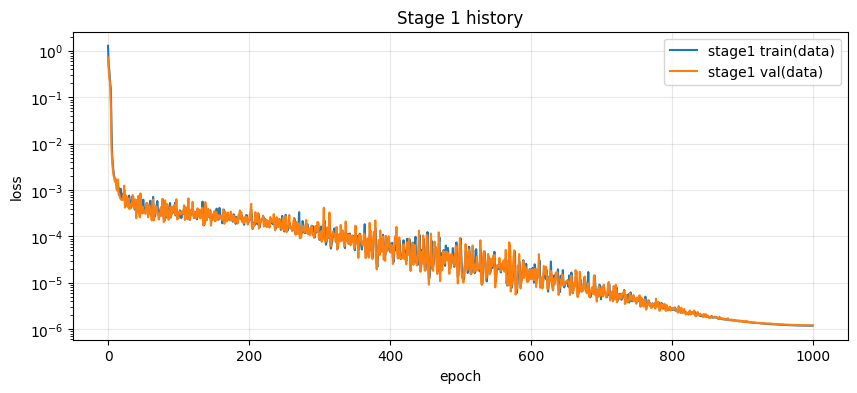

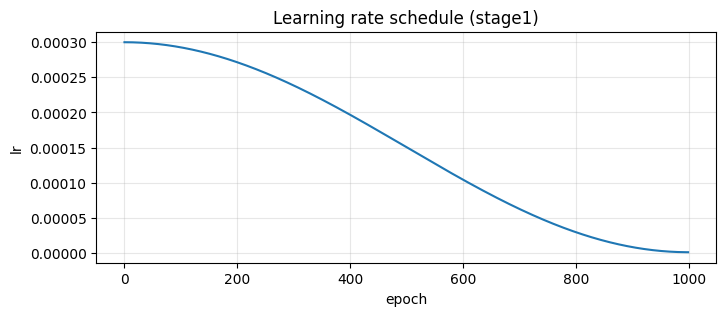

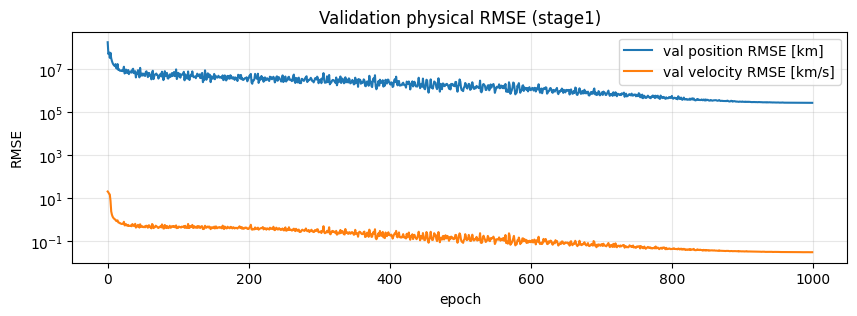

In [2]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import torch

from solsys_emulator.config import DEFAULT_CHECKPOINT_PATH, DEFAULT_DATASET_PATH
from solsys_emulator.de440_dataset import load_dataset
from solsys_emulator.model import ModelConfig
from solsys_emulator.train import TrainConfig, train_emulator

dataset = load_dataset(DEFAULT_DATASET_PATH)
print('Dataset source:', dataset.get('metadata', {}).get('sample_source'))
print('States shape:', dataset['states'].shape)
print('Num samples:', len(dataset['times_seconds']))

device = 'cuda' if torch.cuda.is_available() else 'cpu'

default_ckpt = Path(DEFAULT_CHECKPOINT_PATH)
stage1_ckpt = default_ckpt.with_name('emulator_stage1.pt')
stage2_ckpt = default_ckpt.with_name('emulator_stage2.pt')

# Stage 1: fit puro sui dati (priorita RMSE)
stage1_cfg = TrainConfig(
    epochs=1000,
    batch_size=384,
    lr=3e-4,
    weight_decay=1e-6,
    val_fraction=0.10,
    split_mode='random',
    shuffle=True,
    early_stopping_patience=180,
    lr_scheduler='cosine',
    min_lr=1e-6,
    nbody_loss_weight=0.0,
    physics_loss_weight=0.0,
    smoothness_loss_weight=0.0,
    position_loss_weight=1.0,
    velocity_loss_weight=1.0,
    grad_clip_norm=1.0,
    show_progress=True,
    device=device,
)

model_cfg = ModelConfig(
    num_bodies=len(dataset['bodies']),
    hidden_dim=384,
    num_layers=6,
    fourier_features=24,
    min_frequency=1.0,
    max_frequency=6.0,
    frequency_spacing='linear',
    head_layers=1,
    head_hidden_dim=128,
    dropout=0.0,
)

stage1 = train_emulator(
    dataset,
    train_config=stage1_cfg,
    model_config=model_cfg,
    checkpoint_path=stage1_ckpt,
)

best1_epoch = int(np.argmin(stage1['history']['val_pos_rmse_km'])) + 1
best1_rmse = float(np.min(stage1['history']['val_pos_rmse_km']))
print('Stage1 best epoch:', best1_epoch)
print('Stage1 best val position RMSE [km]:', f'{best1_rmse:,.2f}')

# Stage 2: fine-tuning fisico leggero (puoi disattivarlo se vuoi massimizzare solo il fit)
DO_STAGE2 = False

if DO_STAGE2:
    stage2_cfg = TrainConfig(
        epochs=350,
        batch_size=384,
        lr=8e-5,
        weight_decay=1e-6,
        val_fraction=0.10,
        split_mode='random',
        shuffle=True,
        early_stopping_patience=120,
        lr_scheduler='cosine',
        min_lr=1e-7,
        nbody_loss_weight=0.01,
        nbody_warmup_epochs=120,
        nbody_softening_km=5_000.0,
        nbody_relative_floor_km_s2=1e-5,
        physics_loss_weight=5e-4,
        smoothness_loss_weight=0.0,
        position_loss_weight=1.0,
        velocity_loss_weight=1.0,
        grad_clip_norm=1.0,
        show_progress=True,
        device=device,
    )

    stage2 = train_emulator(
        dataset,
        train_config=stage2_cfg,
        model_config=model_cfg,
        checkpoint_path=stage2_ckpt,
        initial_checkpoint_path=stage1_ckpt,
    )

    best2_epoch = int(np.argmin(stage2['history']['val_pos_rmse_km'])) + 1
    best2_rmse = float(np.min(stage2['history']['val_pos_rmse_km']))
    print('Stage2 best epoch:', best2_epoch)
    print('Stage2 best val position RMSE [km]:', f'{best2_rmse:,.2f}')

    # Mantieni automaticamente il checkpoint con RMSE migliore.
    if best2_rmse <= best1_rmse:
        shutil.copy2(stage2_ckpt, default_ckpt)
        selected = 'stage2'
        selected_artifacts = stage2
        selected_best_rmse = best2_rmse
    else:
        shutil.copy2(stage1_ckpt, default_ckpt)
        selected = 'stage1'
        selected_artifacts = stage1
        selected_best_rmse = best1_rmse
else:
    shutil.copy2(stage1_ckpt, default_ckpt)
    stage2 = None
    selected = 'stage1'
    selected_artifacts = stage1
    selected_best_rmse = best1_rmse

print('Device:', device)
print('Checkpoint finale:', default_ckpt)
print('Stage selezionato:', selected)
print('Best val position RMSE [km]:', f'{selected_best_rmse:,.2f}')

# Plot stage 1
plt.figure(figsize=(10, 4))
plt.plot(stage1['history']['train_loss'], label='stage1 train(data)')
plt.plot(stage1['history']['val_loss'], label='stage1 val(data)')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Stage 1 history')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot stage 2 (se attivo)
if stage2 is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(stage2['history']['train_loss'], label='stage2 train(data)')
    plt.plot(stage2['history']['val_loss'], label='stage2 val(data)')
    plt.plot(stage2['history']['nbody_loss'], label='stage2 nbody')
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Stage 2 history')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plt.figure(figsize=(8, 3))
plt.plot(selected_artifacts['history']['lr'])
plt.title(f'Learning rate schedule ({selected})')
plt.xlabel('epoch')
plt.ylabel('lr')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(selected_artifacts['history']['val_pos_rmse_km'], label='val position RMSE [km]')
plt.plot(selected_artifacts['history']['val_vel_rmse_km_s'], label='val velocity RMSE [km/s]')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('RMSE')
plt.title(f'Validation physical RMSE ({selected})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
